[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **Annotate Your Egocentric Video With MediaPipe**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)

## 1. Imports

Import necessary libraries including MediaPipe, OpenCV, and Matplotlib.

### 📦 Library Overview

| Library | Purpose |
|---|---|
| `mediapipe` | Google's ML framework for hand landmark detection |
| `mediapipe.tasks.python.vision` | High-level Vision Tasks API (HandLandmarker) |
| `urllib.request` | Downloading the model file from Google's CDN |
| `cv2` (OpenCV) | Reading/writing video frames and drawing overlays |
| `numpy` | Array manipulation and frame dtype handling |
| `matplotlib` | Inline frame preview inside the notebook |

> **Note:** Make sure you have installed these dependencies:
> ```bash
> pip install mediapipe opencv-python matplotlib numpy
> ```

In [27]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import HandLandmarker, HandLandmarkerOptions, RunningMode
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2. Download Model

The **MediaPipe Hand Landmarker** model (`hand_landmarker.task`) is a TFLite-based model that detects **21 3D hand landmarks** per hand.

- **Format:** Float16 TFLite (efficient, GPU-friendly)
- **Source:** Google's official MediaPipe model registry
- **Output:** Normalized (x, y, z) coordinates for each landmark

The model is saved locally as `hand_landmarker_full.task` and reused across all detection steps.

In [ ]:

MODEL_URL = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task"
MODEL_PATH = "hand_landmarker_full.task"

urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
print("Full model downloaded!")

Full model downloaded!


### ⚙️ Configuration Parameters Explained

| Parameter | Value | Why |
|---|---|---|
| `running_mode` | `VIDEO` | Enables temporal tracking across frames |
| `num_hands` | `2` | Detect both left and right hand simultaneously |
| `min_hand_detection_confidence` | `0.1` | Low threshold to catch partial/occluded hands |
| `min_hand_presence_confidence` | `0.1` | Keeps tracking even when hand briefly disappears |
| `min_tracking_confidence` | `0.1` | Reduces dropped frames during fast motion |

> **Tip:** For production use with clean footage, raise confidence values to `0.5`+ for fewer false positives.

In [ ]:
# Initialize with new API
options = HandLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=RunningMode.VIDEO,     
    num_hands=2,
    min_hand_detection_confidence=0.1,
    min_hand_presence_confidence=0.1,
    min_tracking_confidence=0.1
)

detector = HandLandmarker.create_from_options(options)
print("Hand detector ready!")

Hand detector ready!


###  Hand Landmark Map

MediaPipe defines **21 landmarks** per hand, numbered 0–20:

```
        8   12  16  20
        |   |   |   |
        7   11  15  19
        |   |   |   |
        6   10  14  18
        |   |   |   |
  4     5   9   13  17
  |      \  |  /   /
  3       \ | /   /
  |        \|/   /
  2    1----0----
```

- **0** = Wrist (palm base, anchor point)
- **1–4** = Thumb (CMC → TIP)
- **5–8** = Index finger (MCP → TIP)
- **9–12** = Middle finger
- **13–16** = Ring finger
- **17–20** = Pinky finger

`HAND_CONNECTIONS` defines the bone pairs to draw the skeleton overlay.

In [30]:
# Landmark names (same 21 points per hand)
HAND_LANDMARKS = {
    0:"WRIST", 1:"THUMB_CMC", 2:"THUMB_MCP", 3:"THUMB_IP", 4:"THUMB_TIP",
    5:"INDEX_MCP", 6:"INDEX_PIP", 7:"INDEX_DIP", 8:"INDEX_TIP",
    9:"MIDDLE_MCP", 10:"MIDDLE_PIP", 11:"MIDDLE_DIP", 12:"MIDDLE_TIP",
    13:"RING_MCP", 14:"RING_PIP", 15:"RING_DIP", 16:"RING_TIP",
    17:"PINKY_MCP", 18:"PINKY_PIP", 19:"PINKY_DIP", 20:"PINKY_TIP"
}

# Connection pairs for drawing skeleton
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),          # Thumb
    (0,5),(5,6),(6,7),(7,8),          # Index
    (0,9),(9,10),(10,11),(11,12),     # Middle
    (0,13),(13,14),(14,15),(15,16),   # Ring
    (0,17),(17,18),(18,19),(19,20),   # Pinky
    (5,9),(9,13),(13,17)              # Palm
]

###  Drawing Function Breakdown

The `draw_landmarks_new()` function does three things:

1. **Converts normalized coordinates → pixel coordinates**  
   Each landmark's `x`, `y` is in range [0, 1]. Multiply by frame width/height to get pixel positions.

2. **Draws the skeleton**  
   Iterates over `HAND_CONNECTIONS` pairs and draws cyan lines (`(0, 200, 255)`) between joints.

3. **Labels each hand**  
   Places a green label (`Left` / `Right`) above the wrist landmark, including the model's confidence score.

**Returns:**
- `annotated` — BGR frame with overlays drawn
- `landmark_data` — dict with `"Left"` and `"Right"` keys, each containing 21 landmark dicts

In [31]:
# Draw function using new API results
def draw_landmarks_new(frame, detection_result):
    h, w = frame.shape[:2]
    annotated = frame.copy()
    landmark_data = {"Left": None, "Right": None}

    if not detection_result.hand_landmarks:
        return annotated, landmark_data

    for hand_landmarks, handedness in zip(
        detection_result.hand_landmarks,
        detection_result.handedness
    ):
        label = handedness[0].category_name   # "Left" or "Right"
        score = handedness[0].score

        # Extract points
        points = []
        for lm in hand_landmarks:
            points.append({
                "x":  lm.x,
                "y":  lm.y,
                "z":  lm.z,
                "px": int(lm.x * w),
                "py": int(lm.y * h)
            })
        landmark_data[label] = points

        # Draw connections
        for (a, b) in HAND_CONNECTIONS:
            x1, y1 = points[a]["px"], points[a]["py"]
            x2, y2 = points[b]["px"], points[b]["py"]
            cv2.line(annotated, (x1, y1), (x2, y2), (0, 200, 255), 2)

        # Draw landmark dots
        for p in points:
            cv2.circle(annotated, (p["px"], p["py"]), 5, (0, 255, 0), -1)

        # Label
        wrist = points[0]
        cv2.putText(annotated, f"{label} ({score:.2f})",
                    (wrist["px"], wrist["py"] - 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    return annotated, landmark_data

###  Video Processing Pipeline

This is the main processing loop. Here's what happens per frame:

```
Read frame (BGR)
     ↓
Convert BGR → RGB
     ↓
Wrap in mp.Image
     ↓
Run detector.detect() [IMAGE mode]
     ↓
draw_landmarks_new() → annotated frame + landmark dict
     ↓
Write annotated frame to output .avi
     ↓
Append landmarks to all_landmarks[]
```

**Why IMAGE mode instead of VIDEO mode here?**  
IMAGE mode avoids timestamp synchronization issues that can cause dropped detections in VIDEO mode when frames are processed at variable speed. Each frame is treated independently.

> **Output:** `output_hands4.avi` — annotated video with hand skeleton overlaid on every frame.

In [ ]:
VIDEO_PATH  = "handwash.mp4"
OUTPUT_PATH = "output_hands4.avi"

cap    = cv2.VideoCapture(VIDEO_PATH)
fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
if fps == 0: fps = 25.0

print(f"Video: {width}x{height} @ {fps:.1f}fps | {total} frames")

fourcc = cv2.VideoWriter_fourcc(*"XVID")
out    = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (width, height))
print("VideoWriter opened:", out.isOpened())

# Create ONE fresh IMAGE-mode detector (same as show_frame uses)
opts_img = HandLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=RunningMode.IMAGE,   # IMAGE mode — no timestamp headaches
    num_hands=2,
    min_hand_detection_confidence=0.2,
    min_hand_presence_confidence=0.2,
)
fresh_detector = HandLandmarker.create_from_options(opts_img)
print("Detector created ✓")

all_landmarks = []
frame_idx     = 0
written_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # MediaPipe needs RGB
    rgb      = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

    #  Use IMAGE mode detect (no timestamp needed)
    result = fresh_detector.detect(mp_image)

    # Draw on BGR frame
    annotated, lm_data = draw_landmarks_new(frame, result)

    # Ensure correct dtype before writing
    annotated = np.ascontiguousarray(annotated, dtype=np.uint8)

    out.write(annotated)
    written_count += 1

    all_landmarks.append({"frame": frame_idx, "landmarks": lm_data})
    frame_idx += 1

    if frame_idx % 50 == 0:
        #  Live check — are landmarks being detected?
        left  = "✓" if lm_data["Left"]  else "✗"
        right = "✓" if lm_data["Right"] else "✗"
        print(f"  Frame {frame_idx}/{total} | L:{left} R:{right}")

cap.release()
out.release()
fresh_detector.close()

print(f"\n✓ Frames written : {written_count}")
print(f"✓ Saved to       : {OUTPUT_PATH}")

Video: 768x432 @ 25.0fps | 353 frames
VideoWriter opened: True
Detector created ✓
  Frame 50/353 | L:✓ R:✗
  Frame 100/353 | L:✗ R:✗
  Frame 150/353 | L:✓ R:✗
  Frame 200/353 | L:✓ R:✗
  Frame 250/353 | L:✓ R:✗
  Frame 300/353 | L:✓ R:✗
  Frame 350/353 | L:✓ R:✗

✓ Frames written : 353
✓ Saved to       : output_hands4.avi


###  JSON Export Format

Each frame is saved as a structured JSON entry:

```json
{
  "frame": 42,
  "hands": {
    "Left": [
      {
        "landmark_id": 0,
        "landmark_name": "WRIST",
        "x": 0.512345,
        "y": 0.789012,
        "z": -0.034567,
        "pixel_x": 328,
        "pixel_y": 504
      },
      ...
    ],
    "Right": null
  }
}
```

- `x`, `y`: Normalized [0–1] coordinates (relative to frame size)
- `z`: Depth estimate — negative = closer to camera
- `pixel_x`, `pixel_y`: Absolute pixel position in the frame
- If a hand is not detected in a frame, its value is `null`

> **Output:** `hand_landmarks.json` — ready for downstream analytics, gesture recognition, or Labellerr import.

In [37]:
import json

# Build JSON structure
output_json = []

for fd in all_landmarks:
    frame_entry = {
        "frame": fd["frame"],
        "hands": {}
    }

    for hand in ["Left", "Right"]:
        pts = fd["landmarks"][hand]
        if pts is None:
            frame_entry["hands"][hand] = None
        else:
            hand_points = []
            for i, p in enumerate(pts):
                hand_points.append({
                    "landmark_id"  : i,
                    "landmark_name": HAND_LANDMARKS[i],
                    "x"            : round(p["x"],  6),   # normalized 0-1
                    "y"            : round(p["y"],  6),   # normalized 0-1
                    "z"            : round(p["z"],  6),   # depth
                    "pixel_x"      : p["px"],              # actual pixel
                    "pixel_y"      : p["py"]               # actual pixel
                })
            frame_entry["hands"][hand] = hand_points

    output_json.append(frame_entry)

# Save to file
JSON_PATH = "hand_landmarks.json"
with open(JSON_PATH, "w") as f:
    json.dump(output_json, f, indent=2)

print(f"✓ Saved: {JSON_PATH}")
print(f"✓ Total frames: {len(output_json)}")
print(f"✓ File size: {os.path.getsize(JSON_PATH)/1024:.1f} KB")

✓ Saved: hand_landmarks.json
✓ Total frames: 353
✓ File size: 1923.1 KB


### Frame Preview Explained

The `show_frame()` function lets you **visually verify** that hand detection is working correctly without processing the entire video.

**What it does:**
1. Seeks to frame `frame_number` (default: frame 30) using `CAP_PROP_POS_FRAMES`
2. Creates a fresh `IMAGE` mode detector
3. Runs detection on that single frame
4. Displays the annotated result inline via `matplotlib`
5. Prints whether Left/Right hands were detected

**Usage tips:**
- Try different frame numbers to sample different moments in the video
- If no hands are detected, lower the `min_hand_detection_confidence` or check lighting/occlusion
- The preview uses `confidence=0.5` — stricter than the batch loop, good for a clean visual check

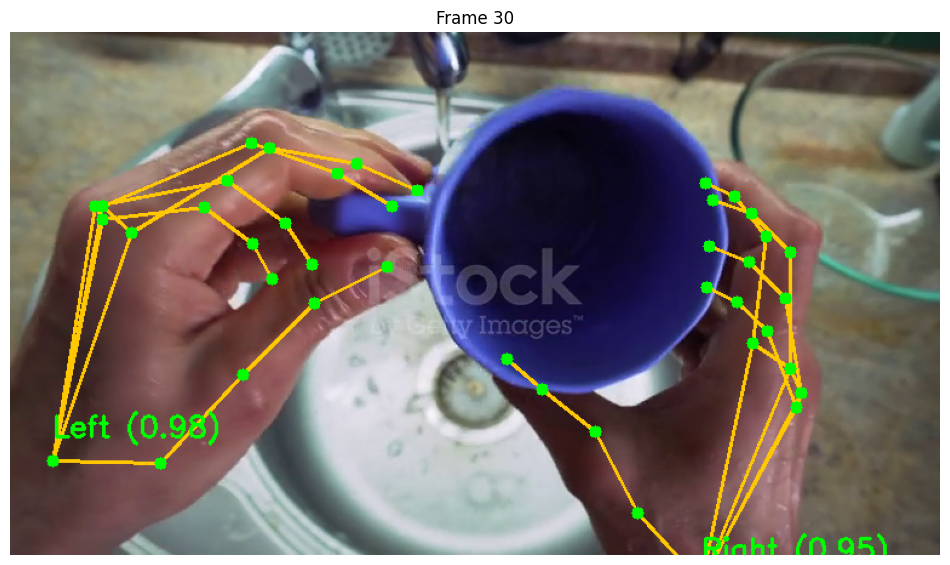

Left: ✓ 21 landmarks
Right: ✓ 21 landmarks


In [34]:
# Preview one frame
def show_frame(frame_number=30):
    cap2 = cv2.VideoCapture(VIDEO_PATH)
    cap2.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap2.read()
    cap2.release()

    opts2 = HandLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=RunningMode.IMAGE,
        num_hands=2,
        min_hand_detection_confidence=0.5,
    )
    det2 = HandLandmarker.create_from_options(opts2)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB,
                        data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    result = det2.detect(mp_image)
    det2.close()

    annotated, lm_data = draw_landmarks_new(frame, result)
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"Frame {frame_number}")
    plt.axis("off")
    plt.show()

    for hand, pts in lm_data.items():
        print(f"{hand}: {'✓ ' + str(len(pts)) + ' landmarks' if pts else 'not detected'}")

show_frame(30)

---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*
